# Middle-Tier CNN implementation

This notebook uses the project dataset from `data/Dataset` for the binary `Fake` vs `Real` classification task. This architecture is modeled from the ResNet-50 example from assignment 4 


In [15]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd


In [16]:
# Load image data from the project data folder using the dataset's existing Train/Validation/Test split
IMAGE_SIZE = (128, 128)
SEED = 7
MAX_TRAIN_PER_CLASS = 10000
MAX_VAL_PER_CLASS = 1500
MAX_TEST_PER_CLASS = 1500
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png'}


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'Dataset').exists():
            return candidate
    raise FileNotFoundError('Could not find data/Dataset from the current notebook location.')


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / 'data' / 'Dataset'
CLASS_NAMES = sorted([path.name for path in (DATA_ROOT / 'Train').iterdir() if path.is_dir()])
CLASS_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}


def load_split(split_name, max_per_class=None):
    split_dir = DATA_ROOT / split_name
    rng = np.random.default_rng(SEED)
    images = []
    labels = []

    for class_name in CLASS_NAMES:
        class_dir = split_dir / class_name
        image_paths = sorted([
            path for path in class_dir.iterdir()
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
        ])

        if max_per_class is not None and len(image_paths) > max_per_class:
            selected_indices = np.sort(rng.choice(len(image_paths), size=max_per_class, replace=False))
            image_paths = [image_paths[index] for index in selected_indices]

        for image_path in image_paths:
            image = keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
            image = keras.utils.img_to_array(image)
            images.append(image)
            labels.append(CLASS_TO_INDEX[class_name])

    x = np.array(images, dtype='float32') / 255.0
    y = np.array(labels, dtype='int32')
    return x, y


x_train, y_train = load_split('Train', MAX_TRAIN_PER_CLASS)
x_val, y_val = load_split('Validation', MAX_VAL_PER_CLASS)
x_test, y_test = load_split('Test', MAX_TEST_PER_CLASS)

print('Project root:', PROJECT_ROOT)
print('Class names:', CLASS_NAMES)
print('x_train shape:', x_train.shape)
print('x_val shape:', x_val.shape)
print('x_test shape:', x_test.shape)
print('y_train shape:', y_train.shape)
print('y_val shape:', y_val.shape)
print('y_test shape:', y_test.shape)


Project root: /Users/nathanjohnson/playground/COMP-487-Project-1
Class names: ['Fake', 'Real']
x_train shape: (20000, 128, 128, 3)
x_val shape: (3000, 128, 128, 3)
x_test shape: (3000, 128, 128, 3)
y_train shape: (20000,)
y_val shape: (3000,)
y_test shape: (3000,)


## Task number one: Implement a simple CNN for Fake vs Real classification


In [17]:
def build_simple_cnn(dropout_rate=0.3):
    inputs = keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))

    x = layers.Conv2D(32, kernel_size=3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Conv2D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(len(CLASS_NAMES), activation='softmax')(x)
    return keras.Model(inputs, outputs, name='SimpleCNN')


In [18]:
model = build_simple_cnn(dropout_rate=0.3)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,506 (365.26 KB)

 Trainable params: 93,506 (365.26 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Train
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(x_val, y_val),
    verbose=2
)


Epoch 1/15
625/625 - 89s - 142ms/step - accuracy: 0.5324 - loss: 0.6894 - val_accuracy: 0.5123 - val_loss: 0.6968
Epoch 2/15
625/625 - 116s - 186ms/step - accuracy: 0.5580 - loss: 0.6847 - val_accuracy: 0.5223 - val_loss: 0.7107
Epoch 3/15
625/625 - 83s - 133ms/step - accuracy: 0.5874 - loss: 0.6753 - val_accuracy: 0.5567 - val_loss: 0.6898
Epoch 4/15
625/625 - 85s - 135ms/step - accuracy: 0.6241 - loss: 0.6535 - val_accuracy: 0.6083 - val_loss: 0.6618
Epoch 5/15
625/625 - 89s - 142ms/step - accuracy: 0.6446 - loss: 0.6355 - val_accuracy: 0.6367 - val_loss: 0.6462
Epoch 6/15
625/625 - 85s - 136ms/step - accuracy: 0.6547 - loss: 0.6258 - val_accuracy: 0.6603 - val_loss: 0.6214
Epoch 7/15
625/625 - 94s - 150ms/step - accuracy: 0.6697 - loss: 0.6131 - val_accuracy: 0.6790 - val_loss: 0.6034
Epoch 8/15
625/625 - 88s - 141ms/step - accuracy: 0.6791 - loss: 0.6049 - val_accuracy: 0.6673 - val_loss: 0.6087
Epoch 9/15
625/625 - 87s - 140ms/step - accuracy: 0.6970 - loss: 0.5865 - val_accuracy:

In [20]:
# Evaluate training and testing accuracy
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f'Training accuracy:   {train_acc:.4f}')
print(f'Validation accuracy: {val_acc:.4f}')
print(f'Testing accuracy:    {test_acc:.4f}')


Training accuracy:   0.8138
Validation accuracy: 0.7470
Testing accuracy:    0.7137


## Confusion Matrix and Classification Metrics

Positive class: Real
           Metric  Value
         Accuracy 0.7137
        Precision 0.6760
           Recall 0.8207
      Specificity 0.6067
         F1 Score 0.7413
Balanced Accuracy 0.7137


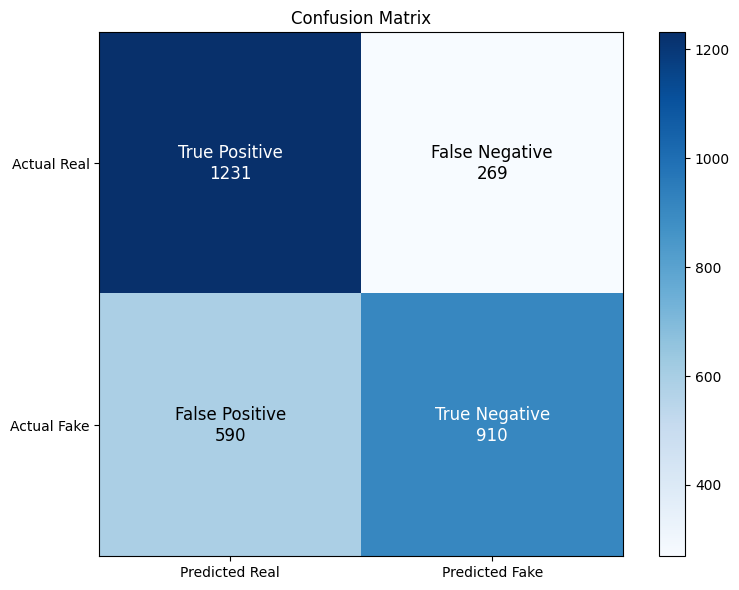

In [26]:
# Confusion matrix and classification metrics on the test set
if len(CLASS_NAMES) != 2:
    raise ValueError('This evaluation cell assumes binary classification.')

POSITIVE_CLASS = 'Real'
NEGATIVE_CLASS = 'Fake'

positive_idx = CLASS_TO_INDEX[POSITIVE_CLASS]
negative_idx = CLASS_TO_INDEX[NEGATIVE_CLASS]

y_test_prob = model.predict(x_test, verbose=0)
y_test_pred = y_test_prob.argmax(axis=1)

tp = int(np.sum((y_test == positive_idx) & (y_test_pred == positive_idx)))
tn = int(np.sum((y_test == negative_idx) & (y_test_pred == negative_idx)))
fp = int(np.sum((y_test == negative_idx) & (y_test_pred == positive_idx)))
fn = int(np.sum((y_test == positive_idx) & (y_test_pred == negative_idx)))

total = tp + tn + fp + fn
accuracy = (tp + tn) / total if total else 0.0
precision = tp / (tp + fp) if (tp + fp) else 0.0
recall = tp / (tp + fn) if (tp + fn) else 0.0
specificity = tn / (tn + fp) if (tn + fp) else 0.0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
balanced_accuracy = (recall + specificity) / 2

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1 Score', 'Balanced Accuracy'],
    'Value': [accuracy, precision, recall, specificity, f1_score, balanced_accuracy]
})

print(f'Positive class: {POSITIVE_CLASS}')
print(metrics_df.to_string(index=False, float_format=lambda value: f'{value:.4f}'))

matrix_counts = np.array([[tp, fn], [fp, tn]])
matrix_labels = np.array([
    ['True Positive', 'False Negative'],
    ['False Positive', 'True Negative']
])

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(matrix_counts, cmap='Blues')
plt.colorbar(image, ax=ax)

ax.set_xticks([0, 1], labels=[f'Predicted {POSITIVE_CLASS}', f'Predicted {NEGATIVE_CLASS}'])
ax.set_yticks([0, 1], labels=[f'Actual {POSITIVE_CLASS}', f'Actual {NEGATIVE_CLASS}'])
ax.set_title('Confusion Matrix')

threshold = matrix_counts.max() / 2 if matrix_counts.size else 0
for row in range(2):
    for col in range(2):
        ax.text(
            col,
            row,
            f'{matrix_labels[row, col]}\n{matrix_counts[row, col]}',
            ha='center',
            va='center',
            color='white' if matrix_counts[row, col] > threshold else 'black',
            fontsize=12
        )

plt.tight_layout()
plt.show()


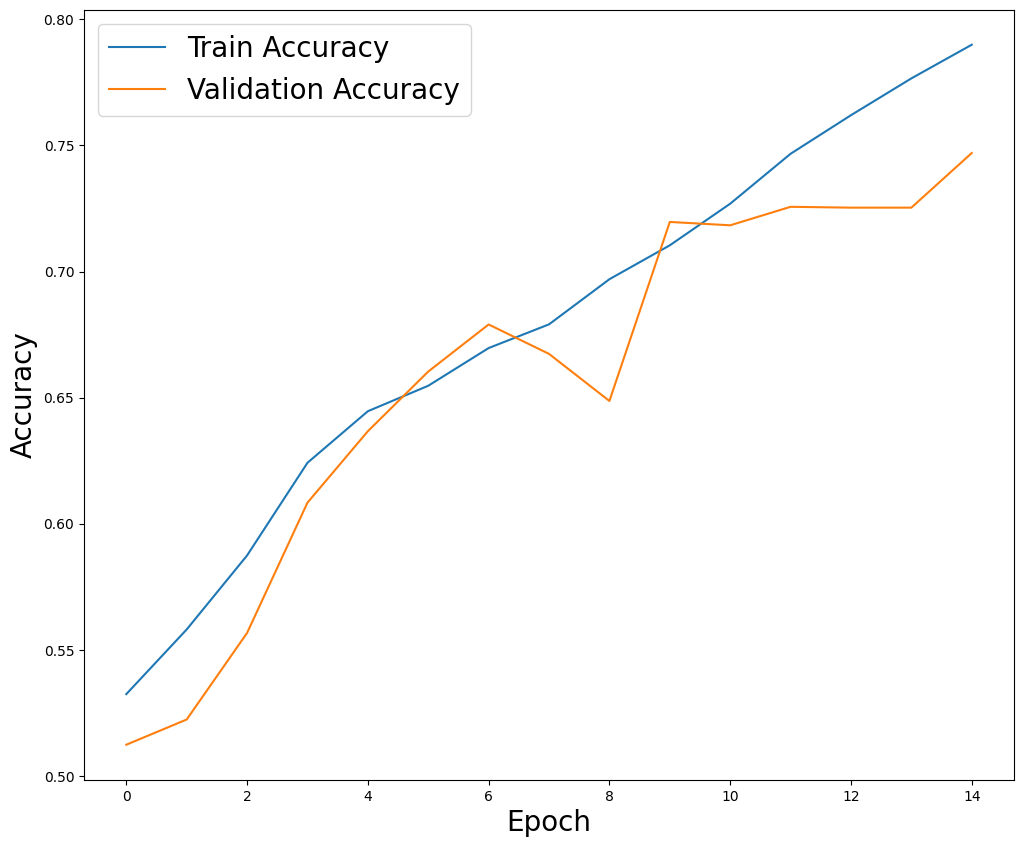

In [22]:
# Visualize training history
def plot_history(hist):
    plt.figure(figsize=(12, 10))
    plt.xlabel('Epoch', fontsize=20)
    plt.ylabel('Accuracy', fontsize=20)
    plt.plot(hist['epoch'], hist['accuracy'], label='Train Accuracy')
    plt.plot(hist['epoch'], hist['val_accuracy'], label='Validation Accuracy')
    plt.legend(loc='upper left', prop={'size': 20})
    plt.show()


hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
plot_history(hist)


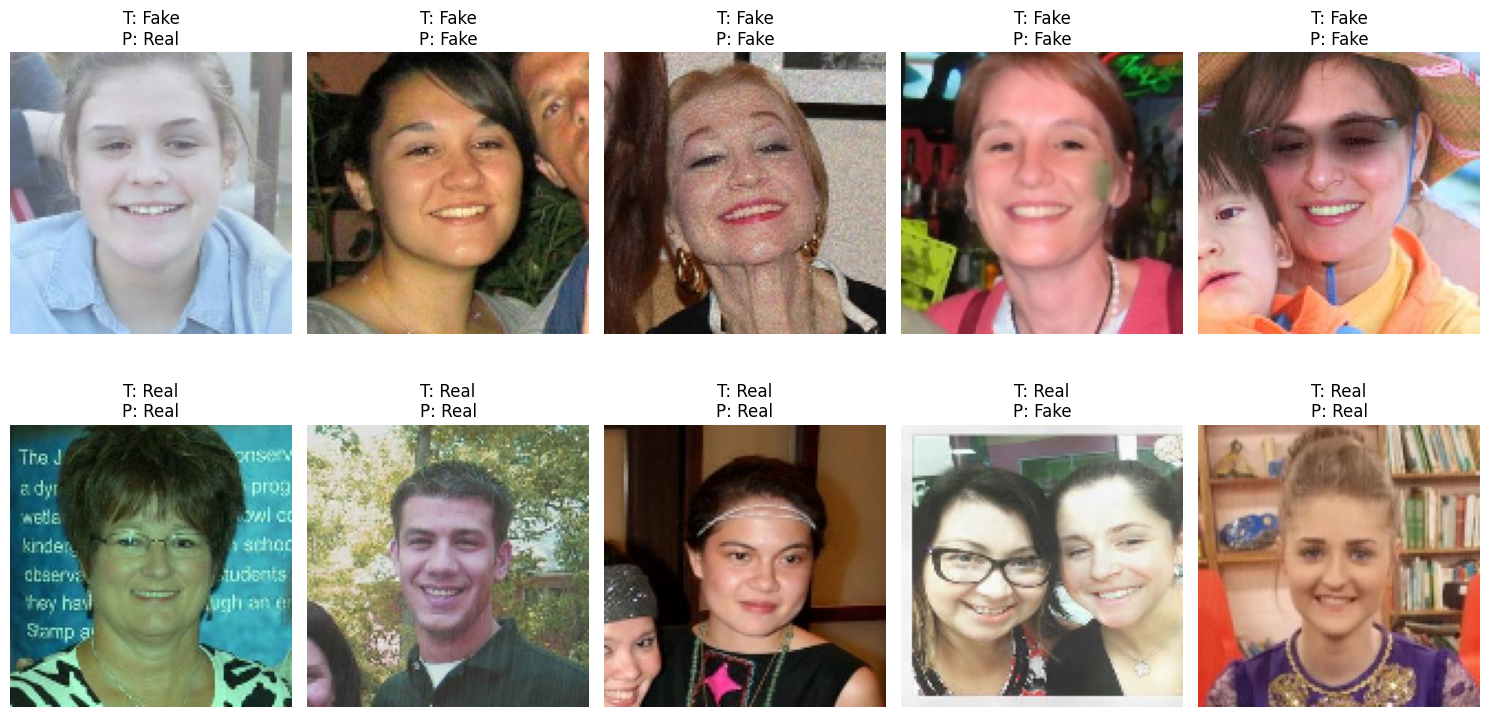

In [23]:
# Predict 5 real and 5 fake images from the test set
real_idx = np.where(y_test == CLASS_TO_INDEX['Real'])[0][:5]
fake_idx = np.where(y_test == CLASS_TO_INDEX['Fake'])[0][:5]
selected_idx = np.concatenate([fake_idx, real_idx])

images = x_test[selected_idx]
labels = y_test[selected_idx]

fig, ax = plt.subplots(2, 5, figsize=(15, 8))
ax = ax.flatten()

for i in range(10):
    img = images[i]
    true_label = labels[i]
    pred = model.predict(img[None, ...], verbose=0).argmax()

    ax[i].imshow(img)
    ax[i].set_title(
        f'T: {CLASS_NAMES[true_label]}\nP: {CLASS_NAMES[pred]}',
        fontsize=12
    )
    ax[i].axis('off')

plt.tight_layout()
plt.show()